# Coefficient of Variation

Coefficient of Variation represents the simple measure of responses variability. It might be used a supportive statistics, however it is advised to use other dispersion and polarization indexes. Coefficient of Variation it is not designed to treat ordinal data where intervals between categories are not equal.

The equation is simple:

$$CV = \frac{\sigma}{\mu} * 100$$

where:

- $\sigma$ is the standard deviation of (numerical) responses
- $\mu$ is the mean of (numerical) responses

You might provide weights to get weighted Coefficient of Variation. Weights array must be the same length as responses array.

## San Francisco City Survey data

This dataset contains processed responses from the `San Francisco City Survey Data` - `https://data.sfgov.org/d/nufj-bfbw`

### Official description

```text
The City Survey asks residents to indicate their usage and satisfaction with city services and infrastructure like libraries, Muni, public safety, and street cleanliness. The City Survey was conducted every year from 1996 to 2004, and biennially from 2005 onward. The City Survey was not conducted in 2019 due to the COVID-19 pandemic, and resumed in 2023. Survey methodology was changed in 2015 from a mail to a phone survey, and expanded to include in-person and online options in 2023.

Comparisons to previous years should be interpreted with caution. Results should be weighted using the column "weight" in order to adjust for demographic differences between the City Survey sample and San Francisco's population. Please note that survey results were originally reported as unweighted until 1997. From 1997 onward, all City Survey results were reweighted with the exception of data from 2011. For ease of use, the column "weight" has been coded with a value of one for these years.

A code book is also attached to this dataset under About > Attachments. Neighborhood and Zip Code data have been hidden from this data set and are only available upon special request to citysurvey@sfgov.org.

For more information regarding San Francisco City Survey 1996-2023 Database,  please visit the City Survey website at https://sf.gov/citysurvey or contact the San Francisco Controller's Office at citysurvey@sfgov.org.
```

### Preprocessing steps

1. Leave columns `['BOSdistrict', 'general_rate', 'muni_rate', 'covid_response']`
2. Drop `NaN` based on the column `'BOSdistrict'`
3. Divide dataset into 3 subsets with non-nan rows, with two columns: `'BOSdistrict'` and one of the following: `'general_rate', 'muni_rate', 'covid_response'`
4. Store `'general_rate', 'muni_rate', 'covid_response'` datasets as csv files
5. Use `'general_rate'` in tutorial.

**Warning**: rates haven't been weighted as is described!

### Citation

```
San Francisco City Survey Data. City Management and Ethics. https://data.sfgov.org/api/views/nufj-bfbw. Issued: 2023-04-11
```

In [3]:
# Imports

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from surveypie.core import info
from surveypie.cov import coeff_of_variation

# Data loading and preparation

In [2]:
df = pd.read_csv('clean-san-francisco-data/processed/general_rate.csv')

### Data exploration

Using `info()` function we can check the basic ordinal statistics: the frequency and ratio of indicator's occurrence in the dataset.

The most common indicator is `3`, followed by `4`. The least common indicator is `1`, followed by `6`.

In [4]:
# Plot and visualize input data

info(df['general_rate'], indicators=range(1, 6))

,frequency,ratio %,cumulative
indicator,,,
1.0,1325,4.265250,0.042653
2.0,3649,11.746338,0.160116
3.0,13385,43.087075,0.590987
4.0,11014,35.454692,0.945534
5.0,1692,5.446644,1.000000


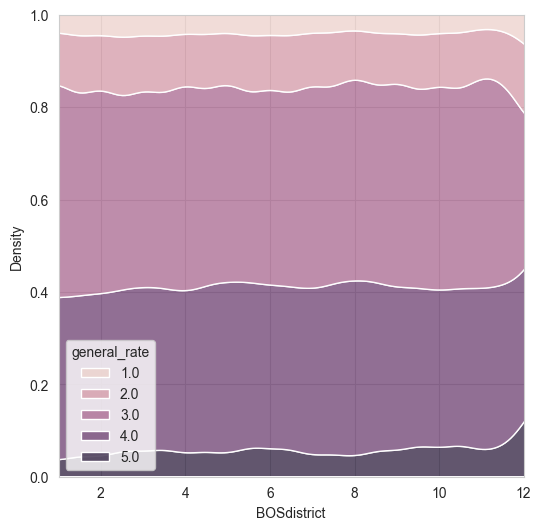

In [5]:
f, ax = plt.subplots(figsize=(6, 6))
sns.kdeplot(data=df, hue='general_rate', x='BOSdistrict', multiple="fill")
ax.set_xlim((1,12))
plt.show()

<Axes: xlabel='BOSdistrict', ylabel='general_rate'>

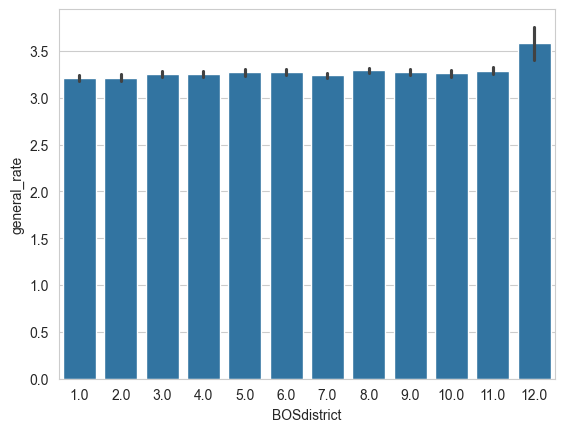

In [6]:
sns.barplot(data=df, y='general_rate', x='BOSdistrict')

## Coefficient of Variation

We are going to calculate CoV for each district and compare the results. The function takes two parameters:

- `responses` - array with numerical grades (responses)
- `weights` - optional, array of the same length are responses, with weights applied to each response

We do not apply weights in this notebook.

In [8]:
# Statistics and calculations

cov_results = df[['general_rate', 'BOSdistrict']].groupby('BOSdistrict')['general_rate'].apply(coeff_of_variation)
cov_results

BOSdistrict
1.0     0.273522
2.0     0.276384
3.0     0.286380
4.0     0.263887
5.0     0.271908
6.0     0.285131
7.0     0.265706
8.0     0.260106
9.0     0.273077
10.0    0.279722
11.0    0.268794
12.0    0.218795
Name: general_rate, dtype: float64

## Summary

The coefficient of variation is lowest for the last district, other districts are fairly close. Looking at graphs, especially the first one, we see that district 12 has more concentrated grades, thus variation is smaller.

## Changelog

- 2026-02-22 : Szymon Moliński (@SimonMolinsky) : first release